In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

#scaling, normalization
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#kmeans, dbscan, hierarchical (sklearn)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
#evaluation
from sklearn.metrics import silhouette_score
#import dataset
from sklearn.datasets import load_iris

#distance matrix (dbscan elbow, hierarchical)
from scipy.spatial.distance import pdist, squareform

# hierarchical (scipy)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [60]:
# Data
data = "data/output/02_data_understanding/clean_data_train.csv"

# Load data
df = pd.read_csv(data)
df.describe()

# theme of plots 'viridis'

,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,numRegions,userReviewsTotal,totalRecognitions,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
count,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,...,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000
mean,7.115757,1990.937029,55.383346,246.218891,51.289249,1.672094,2.711038,2.916661,2.922972,0.596930,...,0.000072,0.001291,0.000789,0.000072,0.014990,0.003658,0.000359,0.002725,0.000072,0.000072
std,1.397509,26.489942,33.982376,884.273132,68.327586,6.534696,2.683848,4.325575,10.489713,2.365819,...,0.008469,0.035908,0.028078,0.008469,0.121515,0.060371,0.018934,0.052136,0.008469,0.008469
min,1.000000,1878.000000,0.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1976.000000,30.000000,15.000000,16.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,1996.000000,50.000000,34.000000,34.000000,0.000000,2.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,2012.000000,90.000000,126.000000,62.000000,1.000000,3.000000,3.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,2024.000000,176.000000,14906.000000,1885.000000,122.000000,8.000000,45.000000,296.000000,49.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

# Funzione per ottenere la matrice di collegamento dal modello di clustering gerarchico
def get_linkage_matrix(model):
    # Create linkage matrix 
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    return linkage_matrix

# Funzione per tracciare il dendrogramma
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

sns.set_theme()
# Definisci i metodi di collegamento
linkage_methods = ['ward', 'complete', 'average', 'single']

# All features


In [62]:
numCol = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

# Normalizza i dati
scaler = MinMaxScaler()
df_Z = scaler.fit_transform(df[numCol])

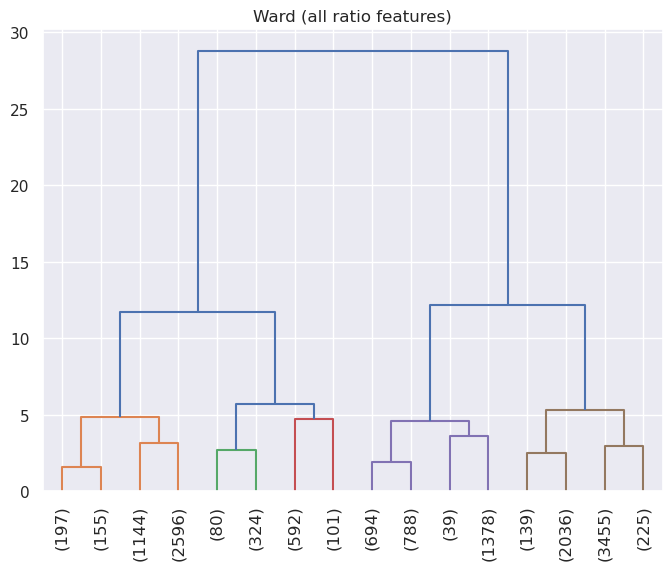

In [72]:
### WARD METHOD
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='ward')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Ward (all ratio features)")
plot_dendrogram(model, p=3, truncate_mode='level', color_threshold=5.3)
# size of the figure
plt.gcf().set_size_inches(8, 6)
plt.xticks(rotation=90)
plt.show()

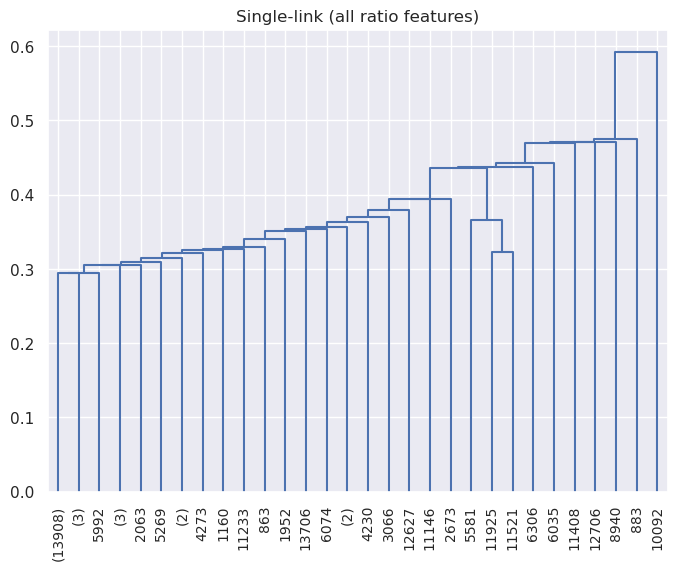

In [64]:
### MIN method
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='single')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Single-link (all ratio features)")
plot_dendrogram(model, p = 30, truncate_mode='lastp', color_threshold=0.0)
plt.gcf().set_size_inches(8, 6)
# rotate x-axis labels
plt.xticks(rotation=90)
plt.show()


In [65]:
numCol = [
# "criticReviewsTotal",
    "numRegions",
#   "numVotes",
  "runtimeMinutes",
  "totalCredits",
#  "totalMedia",
   "totalRecognitions",
# "userReviewsTotal"
]
scaler = MinMaxScaler()
df_Z = scaler.fit_transform(df[numCol])

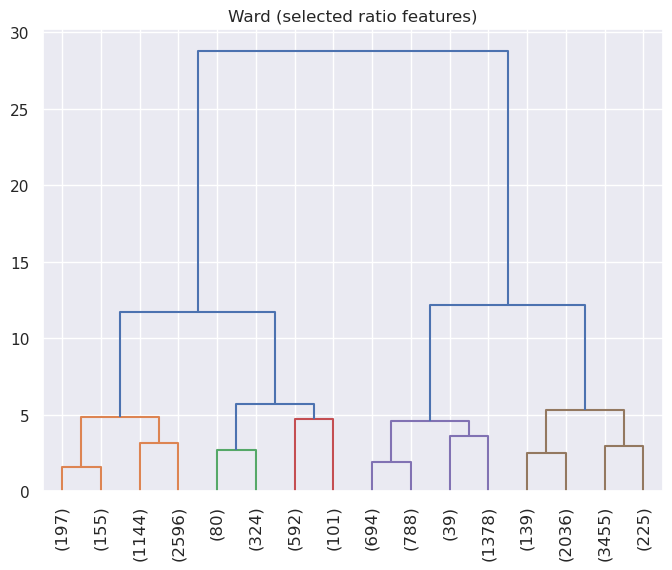

In [71]:
### WARD METHOD
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='ward')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Ward (selected ratio features)")
plot_dendrogram(model, p=3, truncate_mode='level', color_threshold=5.3)
# size of the figure
plt.gcf().set_size_inches(8, 6)
plt.xticks(rotation=90)
plt.show()

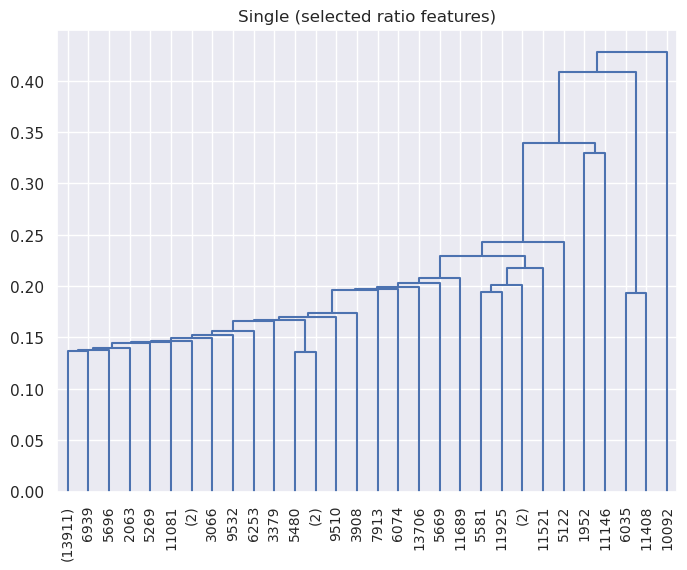

In [67]:
### MIN method
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='single')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Single (selected ratio features)")
plot_dendrogram(model, p = 30, truncate_mode='lastp', color_threshold=0.0)
plt.gcf().set_size_inches(8, 6)
# rotate x-axis labels
plt.xticks(rotation=90)
plt.show()
